# Генераторы. Визуализация в seaborn

## Лекция

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Семя для воспроизводимости (чтобы начальник мог перепроверить)
np.random.seed(42)

# Количество клиентов
n = 500

# Генерация базовых признаков
data = {
    'client_id': range(1, n+1),
    'age': np.random.randint(18, 65, size=n),
    'gender': np.random.choice(['Мужской', 'Женский'], size=n, p=[0.45, 0.55]),
    'loyalty': np.random.choice([0, 1], size=n, p=[0.4, 0.6]), # 60% — участники программы
    'hour': np.random.choice(range(6, 23), size=n, p=[0.1, 0.1, 0.1, 0.05, 0.05, 0.05, 0.05, 0.06, 0.06, 0.06, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.02]), # утро чаще
    'weekday': np.random.choice(['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс'], size=n, p=[0.15, 0.15, 0.15, 0.15, 0.2, 0.1, 0.1]),
    'drink_category': np.random.choice(['Кофе', 'Чай', 'Десерт', 'Смузи'], size=n, p=[0.5, 0.25, 0.15, 0.1])
}

df = pd.DataFrame(data)

# Генерация суммы заказа с заложенными зависимостями
def generate_order_total(row):
    base = np.random.normal(250, 60)  # базовый средний чек 250 рублей

    # Гипотеза А: лояльность увеличивает чек на 30%
    if row['loyalty'] == 1:
        base *= 1.3

    # Гипотеза B: мужчины чуть больше тратят (но разница небольшая)
    if row['gender'] == 'Мужской':
        base *= 1.02

    # Гипотеза C: утром заказы дороже
    if 6 <= row['hour'] <= 10:
        base *= 1.2

    # Гипотеза D: в пятницу вечером — пик
    if row['weekday'] == 'Пт' and 18 <= row['hour'] <= 20:
        base *= 1.4

    # Добавляем шум, чтобы было похоже на реальные данные
    noise = np.random.normal(0, 20)
    return max(50, round(base + noise, 2))  # минимум 50 рублей

df['order_total'] = df.apply(generate_order_total, axis=1)

# Добавим бинарную колонку для "утро/не утро" и "пятница вечер"
df['is_morning'] = df['hour'].between(6, 10).astype(int)
df['is_friday_evening'] = ((df['weekday'] == 'Пт') & (df['hour'].between(18, 20))).astype(int)

print(df.head(10))


   client_id  age   gender  loyalty  hour weekday drink_category  order_total  \
0          1   56  Женский        1    15      Вт           Кофе       344.95   
1          2   46  Женский        1    15      Чт           Кофе       447.88   
2          3   32  Женский        1    17      Вс            Чай       453.23   
3          4   60  Мужской        1     7      Вс           Кофе       285.39   
4          5   25  Женский        0    16      Пн           Кофе       257.09   
5          6   38  Женский        0    20      Вт            Чай       272.57   
6          7   56  Мужской        1     7      Пн           Кофе       259.01   
7          8   36  Мужской        1     8      Пт            Чай       285.50   
8          9   40  Мужской        0    21      Сб            Чай       300.86   
9         10   28  Мужской        0     7      Вт         Десерт       118.73   

   is_morning  is_friday_evening  
0           0                  0  
1           0                  0  
2  

In [5]:
df

,client_id,age,gender,loyalty,hour,weekday,drink_category,order_total,is_morning,is_friday_evening
0,1,56,Женский,1,15,Вт,Кофе,344.95,0,0
1,2,46,Женский,1,15,Чт,Кофе,447.88,0,0
2,3,32,Женский,1,17,Вс,Чай,453.23,0,0
3,4,60,Мужской,1,7,Вс,Кофе,285.39,1,0
4,5,25,Женский,0,16,Пн,Кофе,257.09,0,0
...,...,...,...,...,...,...,...,...,...,...
495,496,37,Женский,1,12,Пн,Кофе,251.89,0,0
496,497,41,Женский,0,19,Чт,Кофе,223.98,0,0
497,498,29,Мужской,1,16,Пн,Кофе,233.42,0,0
498,499,52,Женский,1,17,Пн,Десерт,378.48,0,0


In [7]:
df = df.sample(frac=1)
df

,client_id,age,gender,loyalty,hour,weekday,drink_category,order_total,is_morning,is_friday_evening
381,382,41,Женский,1,6,Вс,Кофе,389.04,1,0
455,456,54,Мужской,1,17,Ср,Кофе,391.10,0,0
408,409,54,Мужской,1,12,Пн,Кофе,291.39,0,0
184,185,56,Мужской,0,18,Пн,Кофе,335.40,0,0
288,289,52,Мужской,1,6,Ср,Кофе,451.20,1,0
...,...,...,...,...,...,...,...,...,...,...
376,377,46,Мужской,1,10,Пн,Смузи,400.43,1,0
317,318,62,Женский,1,16,Чт,Чай,304.38,0,0
301,302,50,Мужской,1,12,Сб,Чай,425.65,0,0
35,36,61,Мужской,1,8,Вт,Кофе,403.09,1,0


In [9]:
df = df.reset_index(drop=True)
df

,client_id,age,gender,loyalty,hour,weekday,drink_category,order_total,is_morning,is_friday_evening
0,382,41,Женский,1,6,Вс,Кофе,389.04,1,0
1,456,54,Мужской,1,17,Ср,Кофе,391.10,0,0
2,409,54,Мужской,1,12,Пн,Кофе,291.39,0,0
3,185,56,Мужской,0,18,Пн,Кофе,335.40,0,0
4,289,52,Мужской,1,6,Ср,Кофе,451.20,1,0
...,...,...,...,...,...,...,...,...,...,...
495,377,46,Мужской,1,10,Пн,Смузи,400.43,1,0
496,318,62,Женский,1,16,Чт,Чай,304.38,0,0
497,302,50,Мужской,1,12,Сб,Чай,425.65,0,0
498,36,61,Мужской,1,8,Вт,Кофе,403.09,1,0


In [11]:
# df.to_csv('data/df_cafe.csv', index = False)

In [12]:
a = pd.read_csv('data/df_cafe.csv')
a

,client_id,age,gender,loyalty,hour,weekday,drink_category,order_total,is_morning,is_friday_evening
0,382,41,Женский,1,6,Вс,Кофе,389.04,1,0
1,456,54,Мужской,1,17,Ср,Кофе,391.10,0,0
2,409,54,Мужской,1,12,Пн,Кофе,291.39,0,0
3,185,56,Мужской,0,18,Пн,Кофе,335.40,0,0
4,289,52,Мужской,1,6,Ср,Кофе,451.20,1,0
...,...,...,...,...,...,...,...,...,...,...
495,377,46,Мужской,1,10,Пн,Смузи,400.43,1,0
496,318,62,Женский,1,16,Чт,Чай,304.38,0,0
497,302,50,Мужской,1,12,Сб,Чай,425.65,0,0
498,36,61,Мужской,1,8,Вт,Кофе,403.09,1,0


In [13]:
df = a.copy()

## Гипотеза A: «Программа лояльности работает!»

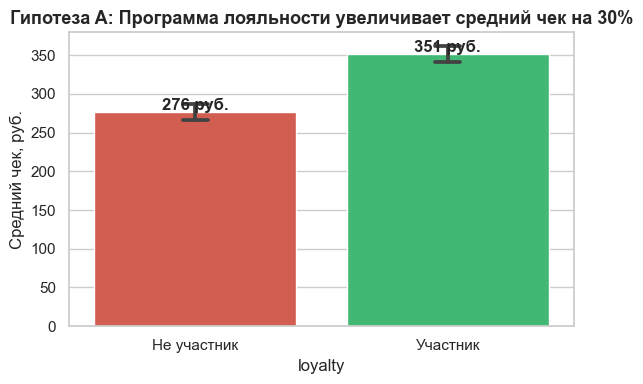

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(6, 4))

# Столбцы с доверительными интервалами
sns.barplot(data=df, x='loyalty', y='order_total', 
            palette=['#E74C3C', '#2ECC71'], 
            capsize=0.1, ax=ax)

ax.set_xticklabels(['Не участник', 'Участник'])
ax.set_ylabel('Средний чек, руб.')
ax.set_title('Гипотеза A: Программа лояльности увеличивает средний чек на 30%', 
             fontsize=13, fontweight='bold')

# Добавляем цифры сверху
for i, p in enumerate(ax.patches):
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 3,
            f'{height:.0f} руб.', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


## Гипотеза B: «Мужчины и женщины тратят одинаково»

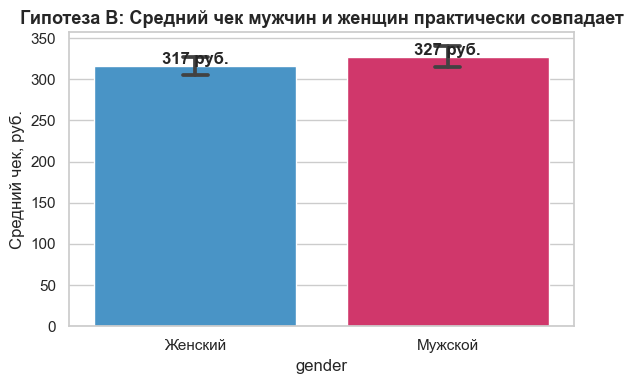

In [15]:
fig, ax = plt.subplots(figsize=(6, 4))

sns.barplot(data=df, x='gender', y='order_total', 
            palette=['#3498DB', '#E91E63'],
            capsize=0.1, ax=ax)

ax.set_ylabel('Средний чек, руб.')
ax.set_title('Гипотеза B: Средний чек мужчин и женщин практически совпадает', 
             fontsize=13, fontweight='bold')

for i, p in enumerate(ax.patches):
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 2,
            f'{height:.0f} руб.', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


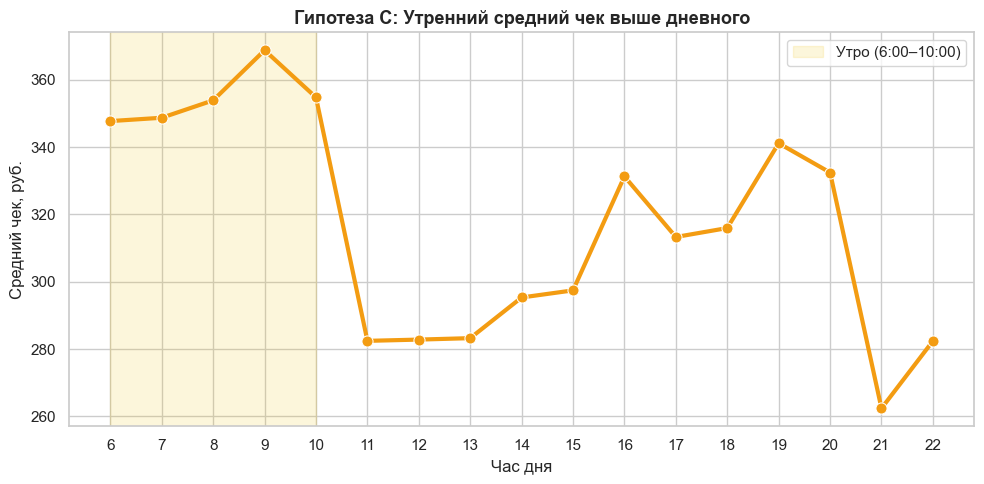

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))

# Почасовые средние
hourly_mean = df.groupby('hour')['order_total'].mean().reset_index()

sns.lineplot(data=hourly_mean, x='hour', y='order_total',
             color='#F39C12', linewidth=3, marker='o', markersize=8, ax=ax)

# Подсветка утра
ax.axvspan(6, 10, alpha=0.15, color='#F1C40F', label='Утро (6:00–10:00)')

ax.set_xlabel('Час дня')
ax.set_ylabel('Средний чек, руб.')
ax.set_title('Гипотеза C: Утренний средний чек выше дневного', 
             fontsize=13, fontweight='bold')
ax.set_xticks(range(6, 23))
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()


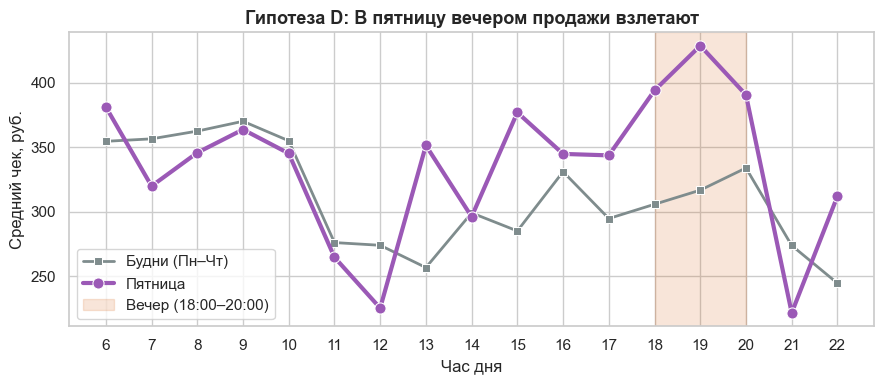

In [18]:
fig, ax = plt.subplots(figsize=(9, 4))

# Сравнение пятницы и будней
hourly_friday = df[df['weekday'] == 'Пт'].groupby('hour')['order_total'].mean().reset_index()
hourly_weekday = df[df['weekday'].isin(['Пн', 'Вт', 'Ср', 'Чт'])].groupby('hour')['order_total'].mean().reset_index()

sns.lineplot(data=hourly_weekday, x='hour', y='order_total', 
             color='#7F8C8D', linewidth=2, marker='s', markersize=6, label='Будни (Пн–Чт)', ax=ax)
sns.lineplot(data=hourly_friday, x='hour', y='order_total', 
             color='#9B59B6', linewidth=3, marker='o', markersize=8, label='Пятница', ax=ax)

ax.axvspan(18, 20, alpha=0.15, color='#D35400', label='Вечер (18:00–20:00)')

ax.set_xlabel('Час дня')
ax.set_ylabel('Средний чек, руб.')
ax.set_title('Гипотеза D: В пятницу вечером продажи взлетают', 
             fontsize=13, fontweight='bold')
ax.set_xticks(range(6, 23))
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()


## Практика

In [38]:
import numpy as np
import pandas as pd

np.random.seed(42)
n = 600

course       = np.random.choice([1, 2, 3, 4], size=n, p=[0.3, 0.3, 0.25, 0.15])
faculty      = np.random.choice(['tech', 'humanities', 'science', 'economics'], size=n)
gender       = np.random.choice(['male', 'female'], size=n)
has_job      = np.random.choice(['yes', 'no'], size=n, p=[0.3, 0.7])

screen_time  = np.round(np.random.uniform(0, 4, n), 1)
caffeine     = np.random.poisson(3, n)
caffeine     = np.clip(caffeine, 0, 8)
exercise     = np.round(np.random.uniform(0, 15, n), 1)

# bedtime: база — около полуночи
bedtime     = np.random.normal(24, 2.5, n)
bedtime     = np.clip(bedtime, 21, 28)          # 28 — это 4 утра

# Качество сна: сперва задаём базовый уровень, потом ухудшаем факторами
sleep_quality  = np.random.normal(7.5, 1.2, n)

# Гипотеза A: screen_time сильно ухудшает сон (подтвердится)
sleep_quality -= 1.2 * screen_time

# Гипотеза B: зависимости от faculty НЕТ (не подтвердится)
# Ничего не добавляем, faculty не влияет

# Гипотеза C: bedtime > 26 (после 2 ночи) ухудшает сон (подтвердится)
sleep_quality[bedtime > 26] -= 2.5

# Добавляем небольшой шум от других факторов
sleep_quality += np.random.normal(0, 0.4, n)

sleep_quality  = np.clip(sleep_quality, 1, 10)
sleep_quality  = np.round(sleep_quality, 1)

df_sleep = pd.DataFrame({
    'student_id':            np.arange(1, n+1),
    'course':                course,
    'faculty':               faculty,
    'screen_time_bed_hours': screen_time,
    'caffeine_cups':         caffeine,
    'exercise_hours_week':   exercise,
    'bedtime_hour':          np.round(bedtime, 0).astype(int),
    'sleep_quality':         sleep_quality,
    'gender':                gender,
    'has_part_time_job':     has_job
})


In [39]:
df_sleep

,student_id,course,faculty,screen_time_bed_hours,caffeine_cups,exercise_hours_week,bedtime_hour,sleep_quality,gender,has_part_time_job
0,1,2,tech,3.8,1,1.0,24,4.6,male,no
1,2,4,humanities,3.0,4,2.8,21,4.4,male,yes
2,3,3,economics,1.4,4,8.3,24,2.7,male,yes
3,4,2,humanities,1.2,1,4.4,28,3.6,female,no
4,5,1,tech,1.4,3,6.3,25,5.3,male,no
...,...,...,...,...,...,...,...,...,...,...
595,596,2,humanities,1.4,3,11.9,22,6.1,female,yes
596,597,3,science,0.6,2,8.6,22,6.4,female,no
597,598,1,humanities,0.1,3,5.1,24,7.1,male,yes
598,599,1,science,2.6,1,12.1,26,4.2,male,yes


In [40]:
df_sleep = df_sleep.sample(frac=1)

In [41]:
df_sleep =  df_sleep.reset_index(drop=True)
df_sleep

,student_id,course,faculty,screen_time_bed_hours,caffeine_cups,exercise_hours_week,bedtime_hour,sleep_quality,gender,has_part_time_job
0,14,1,humanities,0.1,4,4.5,28,5.9,male,no
1,75,3,science,2.9,3,9.4,24,5.1,female,no
2,591,1,tech,1.5,2,5.8,21,6.0,female,yes
3,132,1,humanities,2.2,3,8.3,26,2.4,female,no
4,94,2,tech,0.8,1,3.6,25,7.9,male,no
...,...,...,...,...,...,...,...,...,...,...
595,69,1,tech,0.5,3,11.5,25,8.1,male,no
596,581,2,humanities,3.3,4,9.0,24,3.2,female,yes
597,511,3,tech,2.0,2,4.2,23,4.7,female,yes
598,471,1,humanities,0.4,2,5.8,24,6.1,male,no


In [42]:
# df_sleep.to_csv('data/df_sleep.csv', index=False)

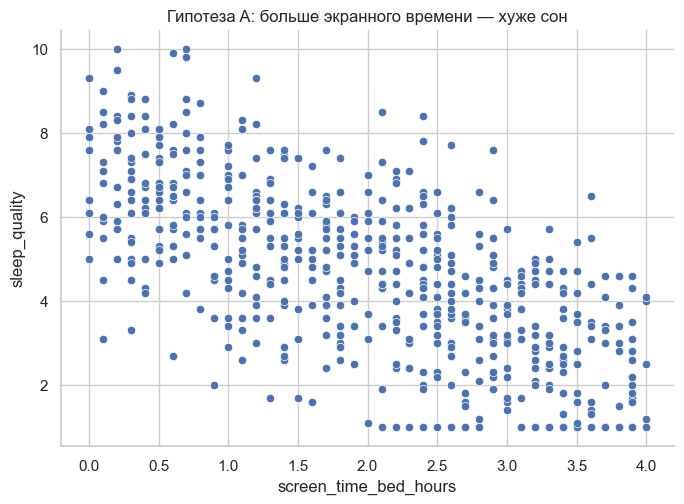

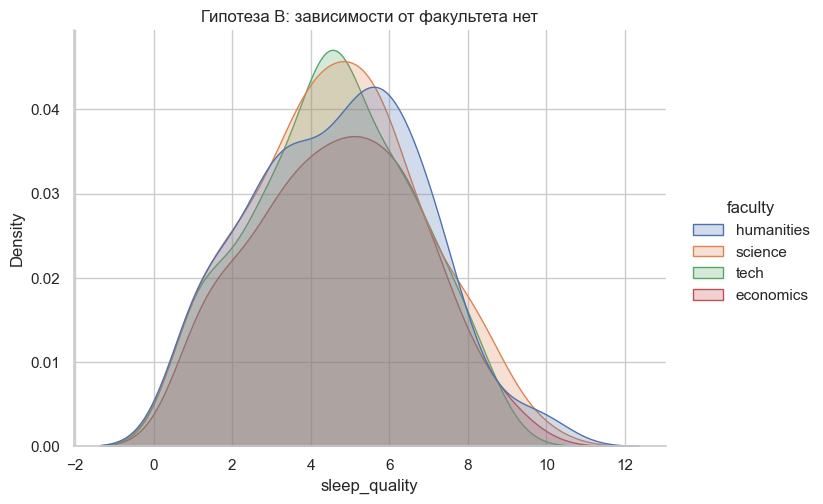

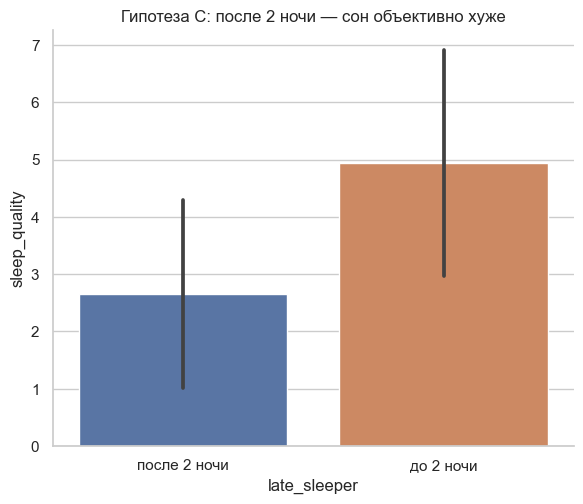

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

# Гипотеза A: связь screen_time и sleep_quality
# relplot с линией тренда — должен показать явный спад
sns.relplot(data=df_sleep, x='screen_time_bed_hours', y='sleep_quality',
            kind='scatter', height=5, aspect=1.4)
plt.title('Гипотеза A: больше экранного времени — хуже сон')
plt.show()

# Гипотеза B: распределения sleep_quality по факультетам
# displot с KDE — наложения должны быть почти идентичны
sns.displot(data=df_sleep, x='sleep_quality', hue='faculty',
            kind='kde', fill=True, height=5, aspect=1.4)
plt.title('Гипотеза B: зависимости от факультета нет')
plt.show()

# Гипотеза C: barplot качества сна для "до 2 ночи" vs "после 2 ночи"
df_sleep['late_sleeper'] = df_sleep['bedtime_hour'].apply(
    lambda h: 'после 2 ночи' if h > 26 else 'до 2 ночи')
sns.catplot(data=df_sleep, x='late_sleeper', y='sleep_quality',
            kind='bar', height=5, aspect=1.2, errorbar='sd')
plt.title('Гипотеза C: после 2 ночи — сон объективно хуже')
plt.show()


## Домашнее задание

In [44]:
np.random.seed(123)
n_days = 365

# Дни года с сезонами
day_id = np.arange(1, n_days+1)
days_in_month = [31,28,31,30,31,30,31,31,30,31,30,31]
months = np.repeat(np.arange(1,13), days_in_month)

season_map = {12: 'winter', 1: 'winter', 2: 'winter',
              3: 'spring', 4: 'spring', 5: 'spring',
              6: 'summer', 7: 'summer', 8: 'summer',
              9: 'autumn', 10: 'autumn', 11: 'autumn'}
season = np.array([season_map[m] for m in months])

# День недели: 0=пн ... 6=вс
weekday_num = (day_id - 1) % 7
is_weekend = np.where(weekday_num >= 5, 'weekend', 'weekday')

# Праздники: ~15 случайных дней в году (не все выходные)
holiday_idx = np.random.choice(n_days, size=15, replace=False)
is_holiday = np.array(['no']*n_days)
is_holiday[holiday_idx] = 'yes'

# Температура по сезонам
temp = np.zeros(n_days)
temp[season=='winter'] = np.random.normal(-2, 5,   sum(season=='winter'))
temp[season=='spring'] = np.random.normal(12, 6,   sum(season=='spring'))
temp[season=='summer'] = np.random.normal(24, 5,   sum(season=='summer'))
temp[season=='autumn'] = np.random.normal(10, 7,   sum(season=='autumn'))
temp = np.round(temp, 1)

# Осадки (много нулей, иногда ливни)
precip = np.random.exponential(3, n_days)
precip = np.round(np.clip(precip, 0, 60), 1)

# Ветер
wind = np.round(np.random.uniform(0, 60, n_days), 1)

# Аренды
rentals = np.random.normal(800, 200, n_days)

# Гипотеза D: сезонность (подтвердится)
rentals[season=='summer'] += 1200
rentals[season=='spring'] += 600
rentals[season=='autumn'] += 400
rentals[season=='winter'] -= 200

# Гипотеза E: ветер портит аренду (НЕ подтвердится — наоборот, ОГЛУШИТЕЛЬНО ПОДТВЕРДИТСЯ)
rentals -= 25 * wind        # сильный негативный эффект

# Гипотеза F: праздники увеличивают аренду (подтвердится)
rentals[is_holiday=='yes'] += 600

# Шум
rentals += np.random.normal(0, 80, n_days)

rentals = np.round(np.clip(rentals, 50, 3500)).astype(int)

df_bikes = pd.DataFrame({
    'day_id':            day_id,
    'season':            season,
    'is_weekend':        is_weekend,
    'temperature_c':     temp,
    'precipitation_mm':  precip,
    'wind_speed_kmh':    wind,
    'is_holiday':        is_holiday,
    'rentals_count':     rentals
})


In [47]:
# df_bikes.to_csv('data/df_bikes.csv', index = False)

In [ ]:
df_bikes

In [31]:
df_bikes['rentals_count'].max()

2329

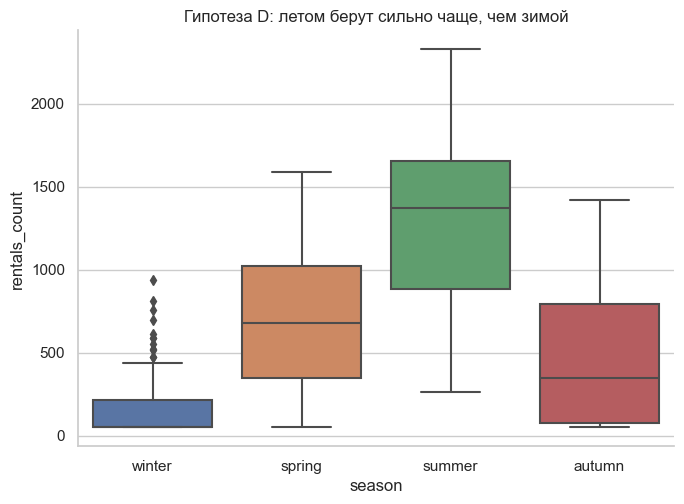

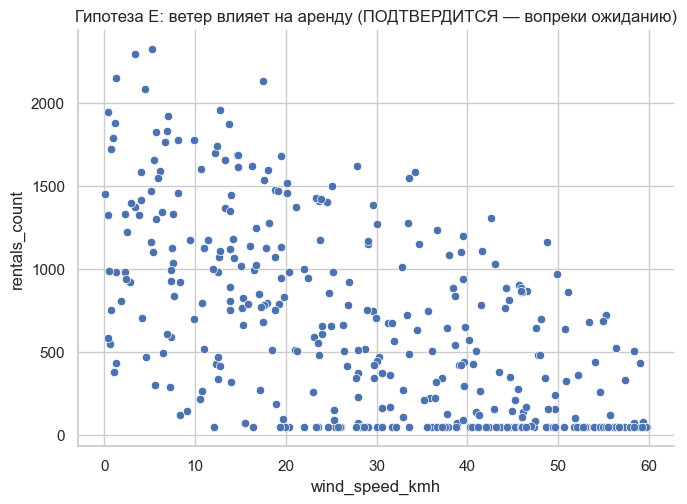

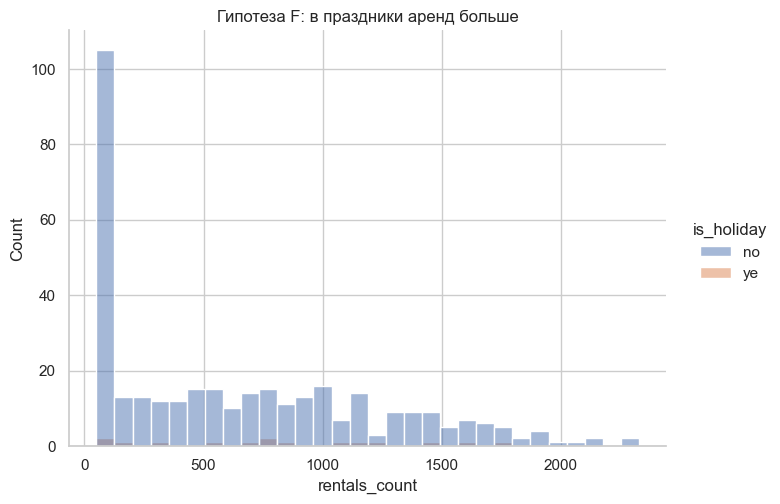

In [27]:
# Гипотеза D: boxplot аренд по сезонам
sns.catplot(data=df_bikes, x='season', y='rentals_count', kind='box',
            order=['winter', 'spring', 'summer', 'autumn'],
            height=5, aspect=1.4)
plt.title('Гипотеза D: летом берут сильно чаще, чем зимой')
plt.show()

# Гипотеза E: связь ветра и аренд — relplot с трендом
sns.relplot(data=df_bikes, x='wind_speed_kmh', y='rentals_count',
            kind='scatter', height=5, aspect=1.4)
plt.title('Гипотеза E: ветер влияет на аренду (ПОДТВЕРДИТСЯ — вопреки ожиданию)')
plt.show()

# Гипотеза F: распределение аренд в праздники vs будни
sns.displot(data=df_bikes, x='rentals_count', hue='is_holiday',
            kind='hist', bins=30, height=5, aspect=1.4, alpha=0.5)
plt.title('Гипотеза F: в праздники аренд больше')
plt.show()
